## Imports

In [1]:
import itk
from tqdm import tqdm
import numpy as np
import os
import SimpleITK as sitk
from pathlib import Path
import warnings
from baselineUtils import (calculate_dice_coefficient, segment_image_with_tissue_model, calculate_tissue_models, show_results, 
load_and_process_images, calculate_probabilities, tissue_prob, relabel, EM, save_probability_atlases)
warnings.filterwarnings("ignore")

## Data Files

In [2]:
train_root_dir = "Training_Set"
subdirs = sorted(os.listdir(train_root_dir))
train_images = []
train_labels = []

for subdir in subdirs:
    train_img_path = os.path.join(train_root_dir, subdir, f"{subdir}_normalized.nii.gz")
    train_lbl_path = os.path.join(train_root_dir, subdir, f"{subdir}_seg.nii.gz")
    train_images.append(train_img_path)
    train_labels.append(train_lbl_path)

val_root_dir = "Validation_Set"
subdirs = sorted(os.listdir(val_root_dir))
val_images = []
val_labels = []

for subdir in subdirs:
    val_img_path = os.path.join(val_root_dir, subdir, f"{subdir}_normalized.nii.gz")
    val_lbl_path = os.path.join(val_root_dir, subdir, f"{subdir}_seg.nii.gz")
    val_images.append(val_img_path)
    val_labels.append(val_lbl_path)

## Registration One vs Rest param:9 affine + elastic to find optimal atlas

In [3]:
best_scores = {}
# Iterate through each potential fixed image
for fixed_file in tqdm(train_images, desc="Fixed Images"):
    if not fixed_file.endswith(('.nii', '.nii.gz')):
        continue
    fixed_image = itk.imread(fixed_file, itk.F)
    fixed_label = itk.imread(fixed_file.replace('_normalized.nii.gz', '_seg.nii.gz'), itk.F)
    files_to_process = [file for file in train_images if file.endswith(('.nii', '.nii.gz')) and file != fixed_file]
    with tqdm(total=len(files_to_process), desc="Registration Progress") as pbar:
        dice_scores = []
        for moving_file in files_to_process:
            moving_image = itk.imread(moving_file, itk.F)
            moving_label = itk.imread(moving_file.replace('_normalized.nii.gz', '_seg.nii.gz'), itk.F)
            # Create a parameter object
            parameter_object = itk.ParameterObject.New()
            parameter_object.AddParameterFile("parameters/9/Parameters.Par0009.affine.txt")
            # add elastic transformation
            parameter_object.AddParameterFile("parameters/9/Parameters.Par0009.elastic.txt")
            result_image, result_transform_parameters = itk.elastix_registration_method(
                fixed_image, moving_image,
                parameter_object=parameter_object,
                log_to_console=False)
            # set the ResampleInterpolator of the result_transform_parameter to "FinalNearestNeighborInterpolator"
            result_transform_parameters.SetParameter("ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
            # use the result_transform_parameters to transform the moving image
            result_label = itk.transformix_filter(moving_label, result_transform_parameters)
            # Calculate dice score between fixed label and transformed moving label
            dice_score = calculate_dice_coefficient(
                itk.GetArrayFromImage(fixed_label),
                itk.GetArrayFromImage(result_label)
            )
            dice_scores.append(dice_score)
            pbar.update(1)
    # Store average dice score for this fixed image
    avg_dice = np.mean(dice_scores)
    best_scores[fixed_file] = avg_dice
    print(f"Average Dice Score for fixed image {fixed_file}: {avg_dice}")
    
# Find the best fixed image
best_fixed_image = max(best_scores.items(), key=lambda x: x[1])
print(f"\nBest fixed image: {best_fixed_image[0]} with average dice score: {best_fixed_image[1]}")

Fixed Images:  10%|█         | 1/10 [02:45<24:45, 165.02s/it]

Average Dice Score for fixed image Training_Set\IBSR_01\IBSR_01_normalized.nii.gz: 0.7881996141843055


Fixed Images:  20%|██        | 2/10 [05:07<20:14, 151.84s/it]

Average Dice Score for fixed image Training_Set\IBSR_03\IBSR_03_normalized.nii.gz: 0.7267073118652391


Fixed Images:  30%|███       | 3/10 [07:30<17:15, 147.87s/it]

...

Average Dice Score for fixed image Training_Set\IBSR_09\IBSR_09_normalized.nii.gz: 0.7761671620182644


Fixed Images:  90%|█████████ | 9/10 [22:14<02:28, 148.63s/it]

Average Dice Score for fixed image Training_Set\IBSR_16\IBSR_16_normalized.nii.gz: 0.755369883201646


Fixed Images: 100%|██████████| 10/10 [24:43<00:00, 148.34s/it]

Average Dice Score for fixed image Training_Set\IBSR_18\IBSR_18_normalized.nii.gz: 0.7930953633512021

Best fixed image: Training_Set\IBSR_18\IBSR_18_normalized.nii.gz with average dice score: 0.7930953633512021


In [6]:
# now we will register all the training images to the best fixed image
fixed_image = itk.imread(best_fixed_image[0], itk.F)
fixed_label = itk.imread(best_fixed_image[0].replace('_normalized.nii.gz', '_seg.nii.gz'), itk.F)
files_to_process = [file for file in train_images if file.endswith(('.nii', '.nii.gz')) and file != best_fixed_image[0]]
output_path = 'registered_training_set/'
os.makedirs(output_path, exist_ok=True)
with tqdm(total=len(files_to_process), desc="Registration Progress") as pbar:
    for moving_file in files_to_process:
        moving_image = itk.imread(moving_file, itk.F)
        moving_label = itk.imread(moving_file.replace('_normalized.nii.gz', '_seg.nii.gz'), itk.F)
        # Create a parameter object
        parameter_object = itk.ParameterObject.New()
        parameter_object.AddParameterFile("parameters/9/Parameters.Par0009.affine.txt")
        # add elastic transformation
        parameter_object.AddParameterFile("parameters/9/Parameters.Par0009.elastic.txt")
        result_image, result_transform_parameters = itk.elastix_registration_method(
            fixed_image, moving_image,
            parameter_object=parameter_object,
            log_to_console=False)
        # set the ResampleInterpolator of the result_transform_parameter to "FinalNearestNeighborInterpolator"
        result_transform_parameters.SetParameter("ResampleInterpolator", ["FinalNearestNeighborInterpolator"])
        # use the result_transform_parameters to transform the moving image
        result_label = itk.transformix_filter(moving_label, result_transform_parameters)
        # save the transformed image and label
        itk.imwrite(result_image, output_path + os.path.basename(moving_file).replace('.nii.gz', '_registered.nii.gz'))
        itk.imwrite(result_label, output_path + os.path.basename(moving_file).replace('_normalized.nii.gz', '_seg_registered.nii.gz'))
        pbar.update(1)

Registration Progress: 100%|██████████| 9/9 [02:26<00:00, 16.31s/it]


## Create Probabilistic Atlas

In [12]:
registered_image_directory = "registered_training_set/"
atlas_directory = "probabAtlas/"
os.makedirs(atlas_directory, exist_ok=True)
reference_image_path = "Training_Set/IBSR_18/IBSR_18_normalized.nii.gz"
num_classes = 4
reference_image = sitk.ReadImage(str(reference_image_path))
reference_image_array = sitk.GetArrayFromImage(reference_image)

num_volumes = 10
reference_shape = reference_image_array.shape
class_labels = {0: 'background', 1: 'csf', 2: 'wm', 3: 'gm'}

# Create accumulators
atlases = np.zeros((num_classes, *reference_shape)).astype('float32')
mean_volume = np.zeros_like(reference_image_array).astype('float32')

for image_name, label_name in zip(Path(registered_image_directory).glob('*_normalized_registered.nii.gz'), Path(registered_image_directory).glob('*_seg_registered.nii.gz')):
    # Mean image
    images = sitk.GetArrayFromImage(sitk.ReadImage(str(image_name)))
    images = (images - images.min()) / (images.max() - images.min()) * 255
    mean_volume += images / num_volumes

    # Probabilistic atlas image
    label_images = sitk.GetArrayFromImage(sitk.ReadImage(str(label_name)))
    for c in range(num_classes):
        atlases[c] += np.where(label_images == c, 1, 0) / num_volumes

# Top Atlas
topological_atlas = np.argmax(atlases, axis=0)

def save_image(data, path, reference_image):
    image = sitk.GetImageFromArray(data)
    image.CopyInformation(reference_image)
    sitk.WriteImage(image, str(path))

# Save probability atlases
for c in range(num_classes):
    save_image(atlases[c], f'./{atlas_directory}probability_atlas_{class_labels[c]}.nii.gz', reference_image)

# Save the topological atlas
save_image(topological_atlas, f'./{atlas_directory}topological_atlas.nii.gz', reference_image)

# Save the mean volume
save_image(mean_volume,f'./{atlas_directory}mean_volume.nii.gz', reference_image)

In [3]:
atlas_directory = "probabAtlas/"
mean_volume = itk.imread(f'./{atlas_directory}mean_volume.nii.gz', itk.F)
topological_atlas = itk.imread(f'./{atlas_directory}topological_atlas.nii.gz', itk.F)
num_classes = 4
class_labels = {0: 'background', 1: 'csf', 2: 'wm', 3: 'gm'}
probability_atlases = [itk.imread(f'./{atlas_directory}probability_atlas_{class_labels[c]}.nii.gz', itk.F) for c in range(num_classes)]

## Create Tissue Models

  0%|          | 0/5 [00:00<?, ?it/s]

Dice Score: CSF: 0.546041412911084, GM: 0.7434572736351177, WM: 0.0013929579490245066, Avg: 0.4302972148317421


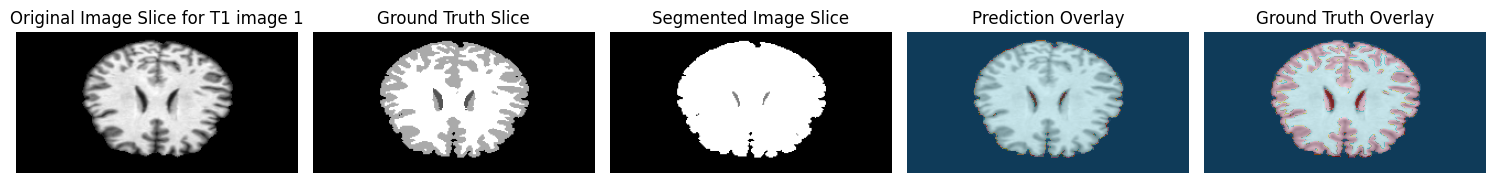

 20%|██        | 1/5 [00:00<00:02,  1.66it/s]

Dice Score: CSF: 0.445440956651719, GM: 0.8400161848122333, WM: 0.4954740897487223, Avg: 0.5936437437375582


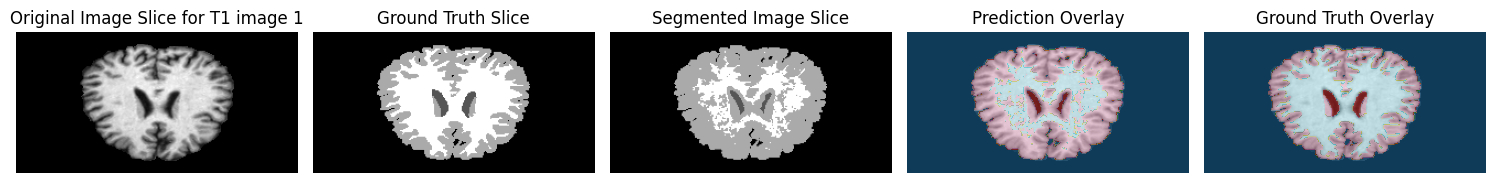

 40%|████      | 2/5 [00:01<00:02,  1.30it/s]

Dice Score: CSF: 0.0019805545552754773, GM: 0.7043349976713145, WM: 0.6252883318224159, Avg: 0.4438679613496686


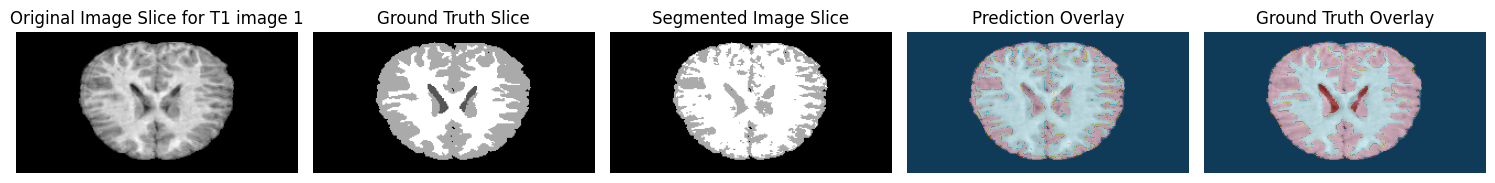

 60%|██████    | 3/5 [00:02<00:01,  1.42it/s]

Dice Score: CSF: 0.00014419610670511897, GM: 0.8294132214990556, WM: 0.7883230231964502, Avg: 0.5392934802674036


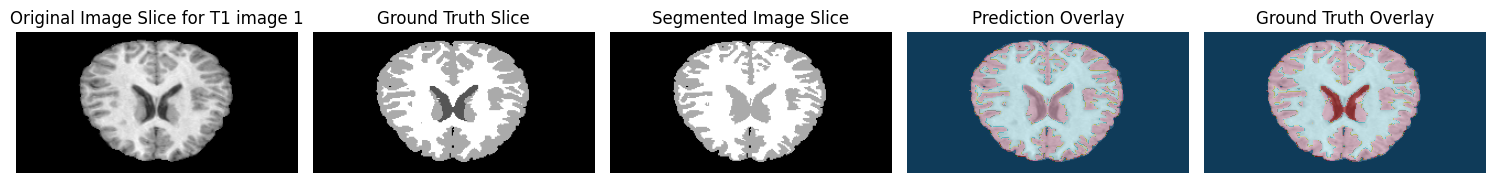

 80%|████████  | 4/5 [00:02<00:00,  1.50it/s]

Dice Score: CSF: 0.001607652425545597, GM: 0.8533242229842298, WM: 0.4694946746903632, Avg: 0.4414755167000462


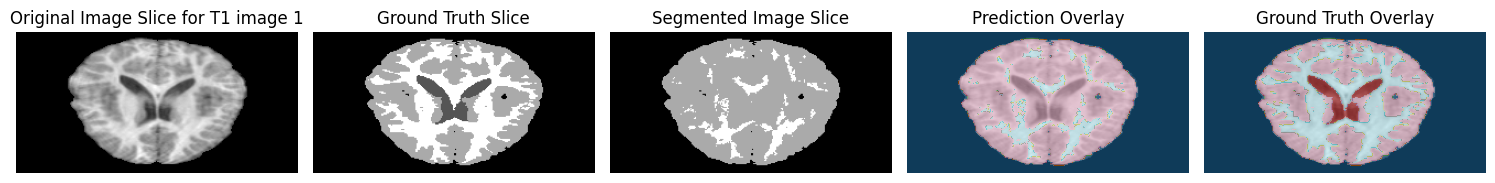

100%|██████████| 5/5 [00:03<00:00,  1.48it/s]


In [14]:
label_histograms_posterior = calculate_tissue_models(train_images, train_labels)
# save the tissue models
save_path = 'tissue_models/'
os.makedirs(save_path, exist_ok=True)
np.save(save_path + 'label_histograms_posterior.npy', label_histograms_posterior)

# Segment validation images using tissue models
for val_image_file in tqdm(val_images, total=len(val_images)):
    val_image_name = os.path.splitext(os.path.splitext(val_image_file)[0])[0]
    val_image = sitk.GetArrayFromImage(sitk.ReadImage(val_image_file))
    gt_label = sitk.GetArrayFromImage(sitk.ReadImage(val_labels[val_images.index(val_image_file)]))
    val_label = segment_image_with_tissue_model(val_image, label_histograms_posterior, gt_label)
    show_results(val_image, gt_label, val_label, modality='T1', i=0, slice_idx=150, plot=True, show_hist=False, cmap='tab20')
    
    # save the segmented image
    # val_label = sitk.GetImageFromArray(val_label)
    # val_label.CopyInformation(sitk.ReadImage(val_image_file))
    # sitk.WriteImage(val_label, f'{save_path}{val_image_name}_segmented.nii.gz')

## EM with Tissue Models

In [8]:
# Process images and calculate probabilities
tissue_data = load_and_process_images(train_images, train_labels)
all_values, probabilities = calculate_probabilities(tissue_data)

100%|██████████| 10/10 [00:01<00:00,  5.41it/s]


Processing image name: Validation_Set\IBSR_11\IBSR_11_normalized.nii.gz with ground truth: Validation_Set\IBSR_11\IBSR_11_seg.nii.gz
Best combination has average dice score of: 0.558608274337249
Dice Score: CSF: 0.0986011885712035, GM: 0.7134692012291269, WM: 0.8637544332114168, Avg: 0.558608274337249


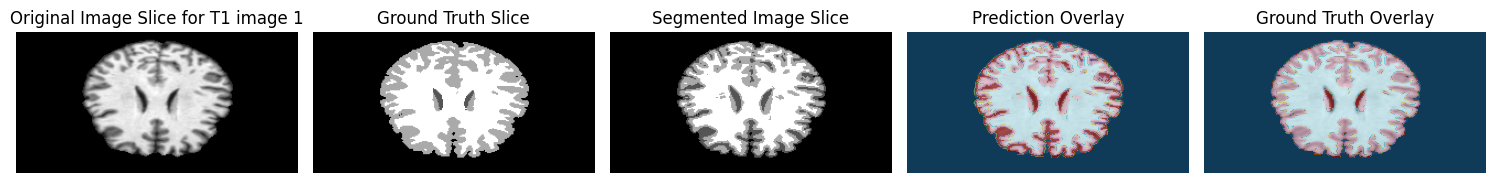

Processing image name: Validation_Set\IBSR_12\IBSR_12_normalized.nii.gz with ground truth: Validation_Set\IBSR_12\IBSR_12_seg.nii.gz
Converged at iteration 165 with log-likelihood -0.0004
Best combination has average dice score of: 0.5525653417261894
Dice Score: CSF: 0.14290657629501877, GM: 0.7505998201244468, WM: 0.7641896287591027, Avg: 0.5525653417261894


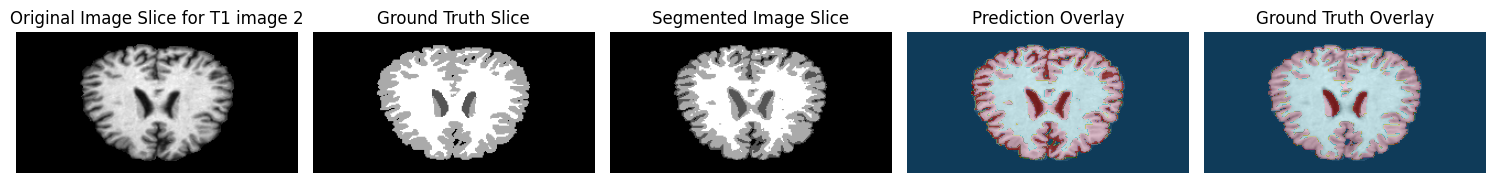

Processing image name: Validation_Set\IBSR_13\IBSR_13_normalized.nii.gz with ground truth: Validation_Set\IBSR_13\IBSR_13_seg.nii.gz
Best combination has average dice score of: 0.5226118865117615
Dice Score: CSF: 0.0005413371026435296, GM: 0.8909540790703735, WM: 0.6763402433622675, Avg: 0.5226118865117615


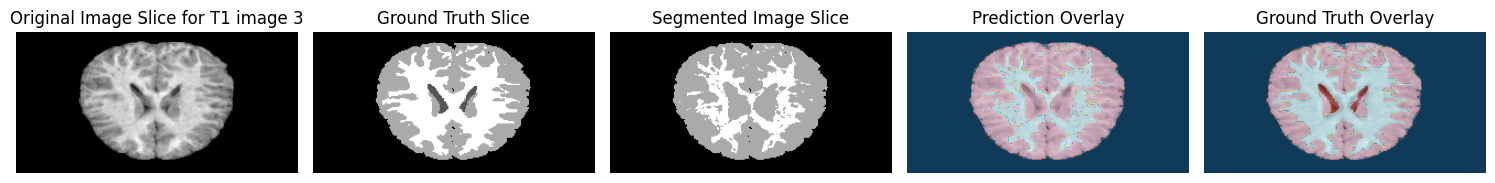

Processing image name: Validation_Set\IBSR_14\IBSR_14_normalized.nii.gz with ground truth: Validation_Set\IBSR_14\IBSR_14_seg.nii.gz
Best combination has average dice score of: 0.6541250729881014
Dice Score: CSF: 0.28509521230051255, GM: 0.8986272787462971, WM: 0.7786527279174945, Avg: 0.6541250729881014


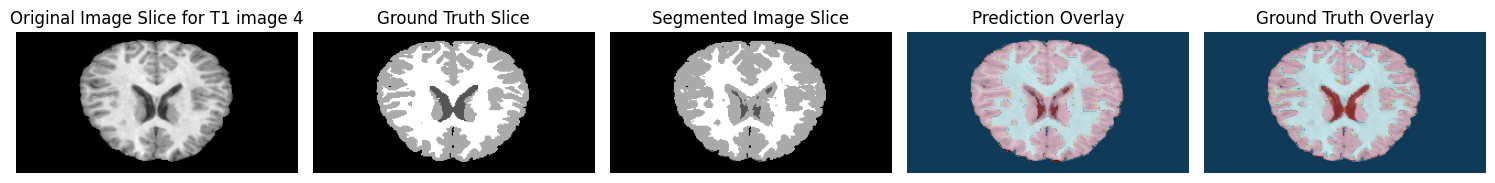

Processing image name: Validation_Set\IBSR_17\IBSR_17_normalized.nii.gz with ground truth: Validation_Set\IBSR_17\IBSR_17_seg.nii.gz
Best combination has average dice score of: 0.6941825939126828
Dice Score: CSF: 0.49803277436112914, GM: 0.8897967815910666, WM: 0.6947182257858527, Avg: 0.6941825939126828


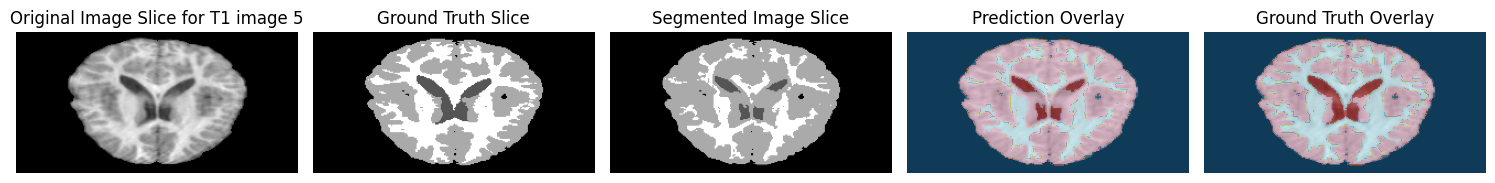

In [4]:
for i, (image_path, gt_path) in enumerate(zip(val_images, val_labels)):
    print(f"Processing image name: {image_path} with ground truth: {gt_path}")
    image = sitk.GetArrayFromImage(sitk.ReadImage(image_path))
    gt = sitk.GetArrayFromImage(sitk.ReadImage(gt_path))
    gt_label = gt.astype(bool)
    
    tissue_probs = tissue_prob(image, gt, probabilities, all_values)
    response = EM(data=image, data_label=None, init='other', mask=gt_label, init_weights=tissue_probs, comb_mode='no', atlas_weights=None, freq=0, max_iter=200)
    label_em = np.zeros_like(image)
    label_em[gt_label] = response + 1
    relabeled_image, segmentation, best_score = relabel(gt, label_em, image)
    show_results(image, gt, segmentation, modality='T1', i=i, slice_idx=150, plot=True, show_hist=False, cmap='tab20')
    
    # save the segmented image
    # segmentation = sitk.GetImageFromArray(segmentation)
    # segmentation.CopyInformation(sitk.ReadImage(os.path.join(test_image_directory, f'{patient_ID}.nii.gz')))
    # sitk.WriteImage(segmentation, f'./tm-em-segmentations/{patient_ID}_segmented.nii.gz')

## EM with Label Propagation

In [4]:
# save all registered probability atlases for val images
# to get the probability atlases for the val images, we need to register the mean volume  to the val images, then transform the probability atlases to the val images, and save them
# now we get the probability atlases for the val images for use in the EM algorithm
save_probability_atlases(
    val_image_paths=val_images,
    mean_volume=mean_volume,
    probability_atlases=probability_atlases,
    topological_atlas=topological_atlas,
    class_labels=class_labels,
    output_dir="val_probability_atlases"
)

Processing images: 100%|██████████| 5/5 [01:50<00:00, 22.06s/it]


Processing image name: Validation_Set\IBSR_11\IBSR_11_normalized.nii.gz with ground truth: Validation_Set\IBSR_11\IBSR_11_seg.nii.gz
Converged at iteration 66 with log-likelihood -0.0004
Best combination has average dice score of: 0.5966517267869068
Dice Score: CSF: 0.0025780189959294436, GM: 0.912575452079852, WM: 0.874801709284939, Avg: 0.5966517267869068


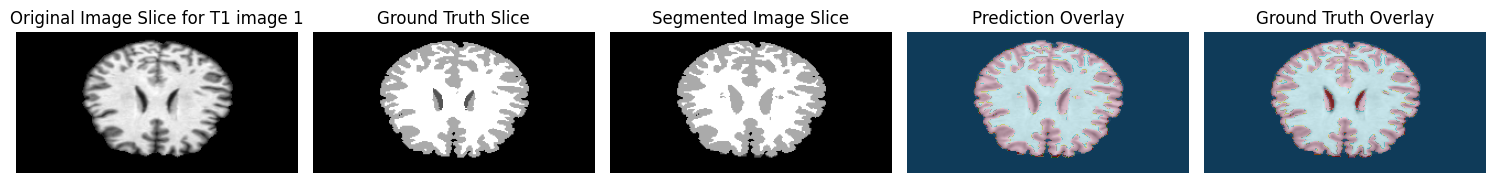

Processing image name: Validation_Set\IBSR_12\IBSR_12_normalized.nii.gz with ground truth: Validation_Set\IBSR_12\IBSR_12_seg.nii.gz
Best combination has average dice score of: 0.5783362611539583
Dice Score: CSF: 0.17520371662238582, GM: 0.7995323920071741, WM: 0.7602726748323151, Avg: 0.5783362611539583


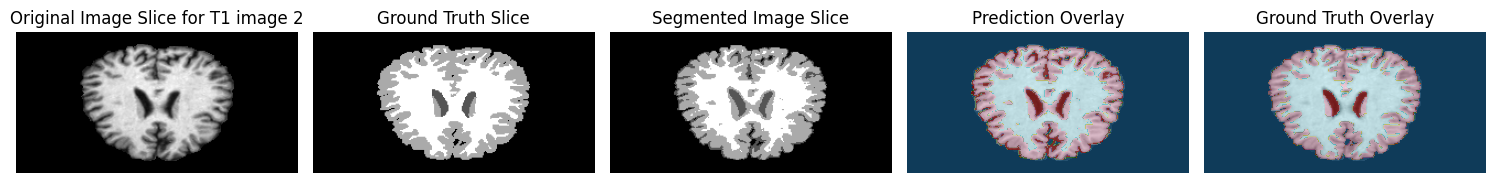

Processing image name: Validation_Set\IBSR_13\IBSR_13_normalized.nii.gz with ground truth: Validation_Set\IBSR_13\IBSR_13_seg.nii.gz
Best combination has average dice score of: 0.5224533465373126
Dice Score: CSF: 0.0005413371026435296, GM: 0.8908820796870148, WM: 0.6759366228222794, Avg: 0.5224533465373126


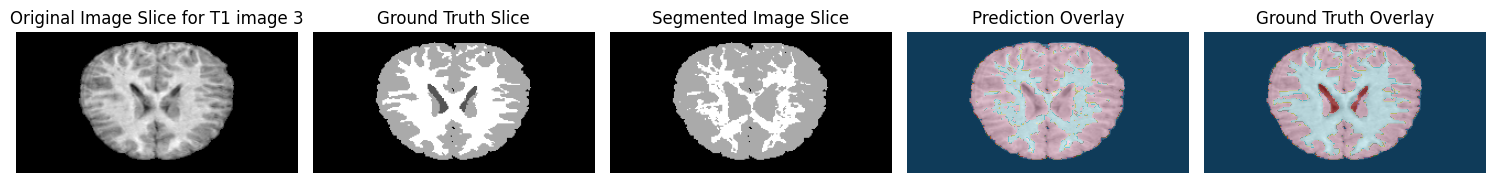

Processing image name: Validation_Set\IBSR_14\IBSR_14_normalized.nii.gz with ground truth: Validation_Set\IBSR_14\IBSR_14_seg.nii.gz
Best combination has average dice score of: 0.6536368450787264
Dice Score: CSF: 0.2850237519793316, GM: 0.8983336288476458, WM: 0.7775531544092018, Avg: 0.6536368450787264


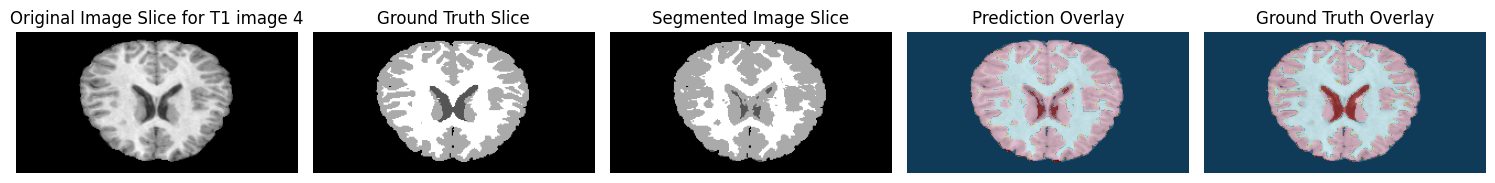

Processing image name: Validation_Set\IBSR_17\IBSR_17_normalized.nii.gz with ground truth: Validation_Set\IBSR_17\IBSR_17_seg.nii.gz
Best combination has average dice score of: 0.6941825939126828
Dice Score: CSF: 0.49803277436112914, GM: 0.8897967815910666, WM: 0.6947182257858527, Avg: 0.6941825939126828


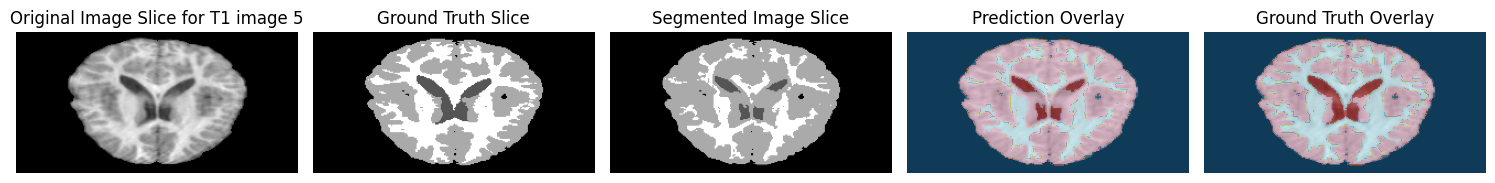

In [6]:
for i, (image_path, gt_path) in enumerate(zip(val_images, val_labels)):
    print(f"Processing image name: {image_path} with ground truth: {gt_path}")
    image = sitk.GetArrayFromImage(sitk.ReadImage(image_path))
    gt = sitk.GetArrayFromImage(sitk.ReadImage(gt_path))
    gt_label = gt.astype(bool)
    prob_atlases = [itk.imread(f'./val_probability_atlases/{os.path.splitext(image_path)[0]}/probability_atlas_{class_labels[c]}.nii.gz', itk.F) for c in range(num_classes)]
    prob_atlas = {}
    probabilitic_atlas = [itk.GetArrayFromImage(prob_atlases[i]) for i in range(1, num_classes)]
    probabilitic_atlas = [atlas[gt_label] for atlas in probabilitic_atlas]
    seg = np.stack(probabilitic_atlas, axis=0)

    response = EM(data=image, data_label=None, init='other', mask=gt_label, init_weights=seg, comb_mode='no', atlas_weights=None, freq=0, max_iter=200)
    label_em = np.zeros_like(image)
    label_em[gt_label] = response + 1
    relabeled_image, segmentation, best_score = relabel(gt, label_em, image)
    show_results(image, gt, segmentation, modality='T1', i=i, slice_idx=150, plot=True, show_hist=False, cmap='tab20')

## EM with label propagation and tissue models (into(1, 3, 10) and a-posteriori).

### A posteriori

Processing image name: Validation_Set\IBSR_11\IBSR_11_normalized.nii.gz with ground truth: Validation_Set\IBSR_11\IBSR_11_seg.nii.gz
Best combination has average dice score of: 0.8468778892907421
Dice Score: CSF: 0.7378025206835228, GM: 0.9246256666490774, WM: 0.8782054805396261, Avg: 0.8468778892907421


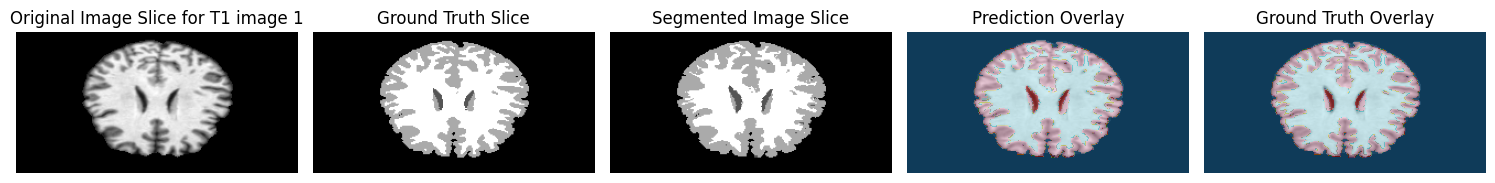

Processing image name: Validation_Set\IBSR_12\IBSR_12_normalized.nii.gz with ground truth: Validation_Set\IBSR_12\IBSR_12_seg.nii.gz
Converged at iteration 165 with log-likelihood -0.0004
Best combination has average dice score of: 0.7986495838259878
Dice Score: CSF: 0.6532457691336196, GM: 0.9161480224790585, WM: 0.8265549598652854, Avg: 0.7986495838259878


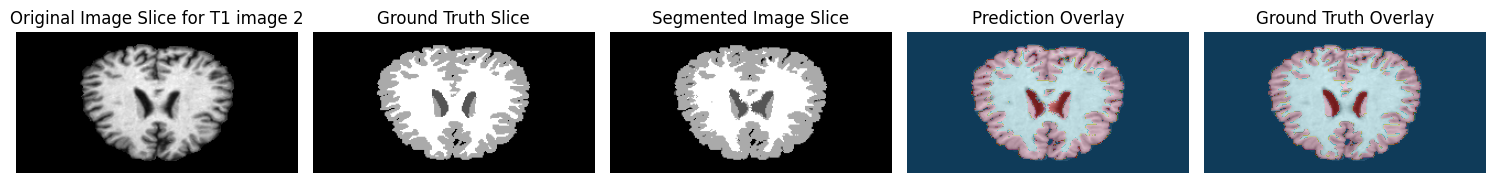

Processing image name: Validation_Set\IBSR_13\IBSR_13_normalized.nii.gz with ground truth: Validation_Set\IBSR_13\IBSR_13_seg.nii.gz
Best combination has average dice score of: 0.7205585472737382
Dice Score: CSF: 0.4044804464943219, GM: 0.9321234416837109, WM: 0.8250717536431822, Avg: 0.7205585472737382


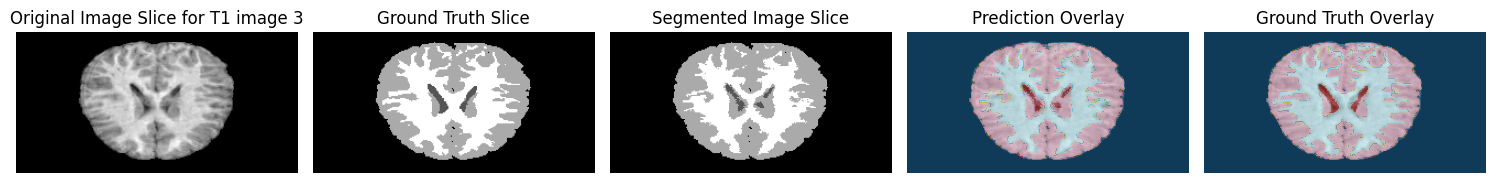

Processing image name: Validation_Set\IBSR_14\IBSR_14_normalized.nii.gz with ground truth: Validation_Set\IBSR_14\IBSR_14_seg.nii.gz
Best combination has average dice score of: 0.8300514947000579
Dice Score: CSF: 0.7310801189429158, GM: 0.923911322515336, WM: 0.8351630426419218, Avg: 0.8300514947000579


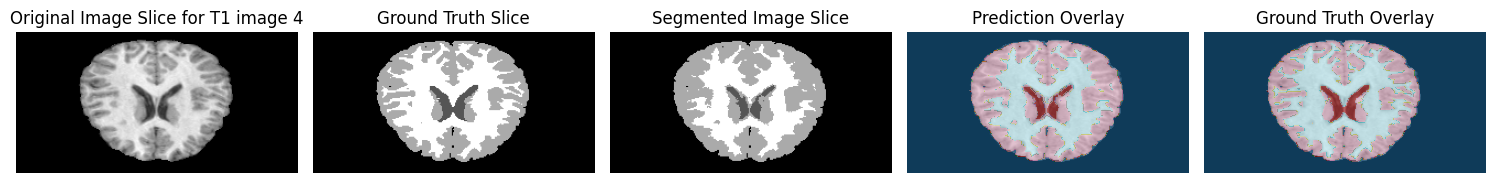

Processing image name: Validation_Set\IBSR_17\IBSR_17_normalized.nii.gz with ground truth: Validation_Set\IBSR_17\IBSR_17_seg.nii.gz
Best combination has average dice score of: 0.8569618167134858
Dice Score: CSF: 0.8398694901157955, GM: 0.9242196743255608, WM: 0.8067962856991011, Avg: 0.8569618167134858


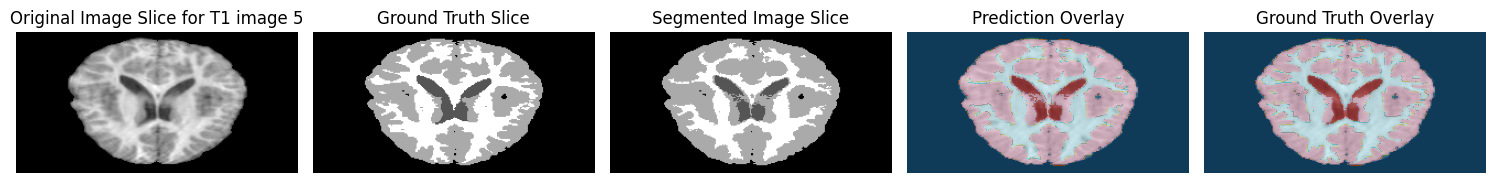

In [9]:
for i, (image_path, gt_path) in enumerate(zip(val_images, val_labels)):
    print(f"Processing image name: {image_path} with ground truth: {gt_path}")
    image = sitk.GetArrayFromImage(sitk.ReadImage(image_path))
    gt = sitk.GetArrayFromImage(sitk.ReadImage(gt_path))
    gt_label = gt.astype(bool)
    
    tissue_probs = tissue_prob(image, gt, probabilities, all_values)
    prob_atlases = [itk.imread(f'./val_probability_atlases/{os.path.splitext(image_path)[0]}/probability_atlas_{class_labels[c]}.nii.gz', itk.F) for c in range(num_classes)]
    prob_atlas = {}
    probabilitic_atlas = [itk.GetArrayFromImage(prob_atlases[i]) for i in range(1, num_classes)]
    probabilitic_atlas = [atlas[gt_label] for atlas in probabilitic_atlas]
    seg = np.stack(probabilitic_atlas, axis=0)
    
    response = EM(data=image, data_label=None, init='other', mask=gt_label, init_weights=tissue_probs, comb_mode='end', atlas_weights=seg, freq=0, max_iter=200)
    label_em = np.zeros_like(image)
    label_em[gt_label] = response + 1
    relabeled_image, segmentation, best_score = relabel(gt, label_em, image)
    show_results(image, gt, segmentation, modality='T1', i=i, slice_idx=150, plot=True, show_hist=False, cmap='tab20')

### Into EM with freq=1

Processing image name: Validation_Set\IBSR_11\IBSR_11_normalized.nii.gz with ground truth: Validation_Set\IBSR_11\IBSR_11_seg.nii.gz
Converged at iteration 3 with log-likelihood -0.0000
Best combination has average dice score of: 0.8564784041412595
Dice Score: CSF: 0.746601834456846, GM: 0.9275992686585056, WM: 0.895234109308427, Avg: 0.8564784041412595


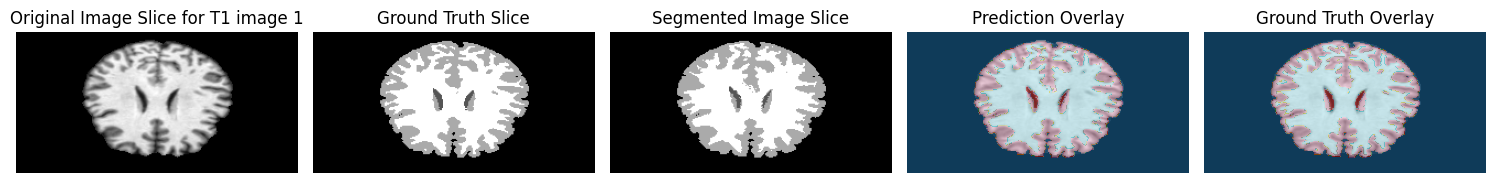

Processing image name: Validation_Set\IBSR_12\IBSR_12_normalized.nii.gz with ground truth: Validation_Set\IBSR_12\IBSR_12_seg.nii.gz
Converged at iteration 2 with log-likelihood -0.0000
Best combination has average dice score of: 0.8662932964102588
Dice Score: CSF: 0.7809315581931051, GM: 0.9364796065824519, WM: 0.8814687244552194, Avg: 0.8662932964102588


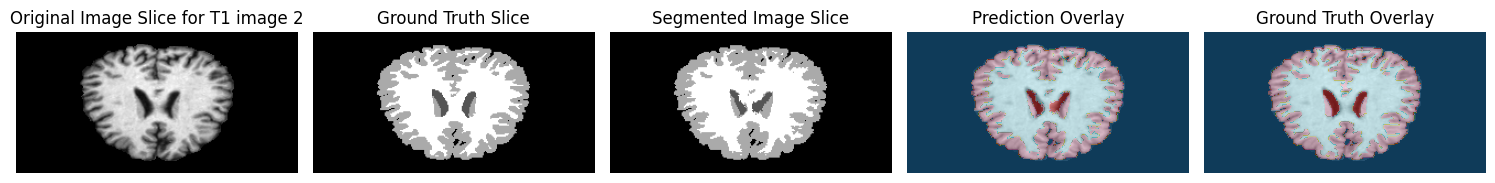

Processing image name: Validation_Set\IBSR_13\IBSR_13_normalized.nii.gz with ground truth: Validation_Set\IBSR_13\IBSR_13_seg.nii.gz
Converged at iteration 6 with log-likelihood -0.0000
Best combination has average dice score of: 0.7477105432338816
Dice Score: CSF: 0.4725294783338809, GM: 0.9256657390518336, WM: 0.8449364123159304, Avg: 0.7477105432338816


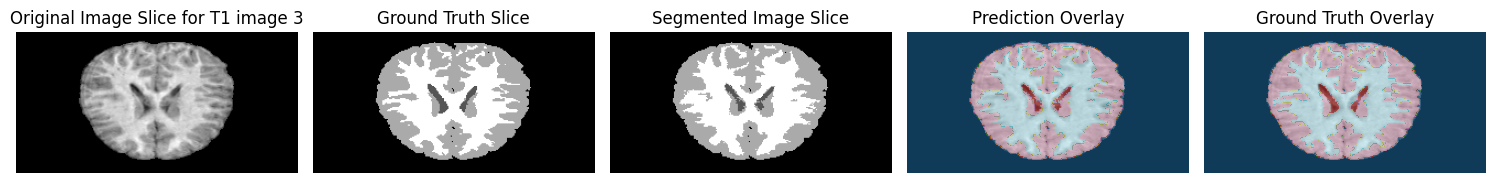

Processing image name: Validation_Set\IBSR_14\IBSR_14_normalized.nii.gz with ground truth: Validation_Set\IBSR_14\IBSR_14_seg.nii.gz
Converged at iteration 5 with log-likelihood -0.0000
Best combination has average dice score of: 0.8594625257158679
Dice Score: CSF: 0.7543218894570246, GM: 0.9380099879846459, WM: 0.8860556997059332, Avg: 0.8594625257158679


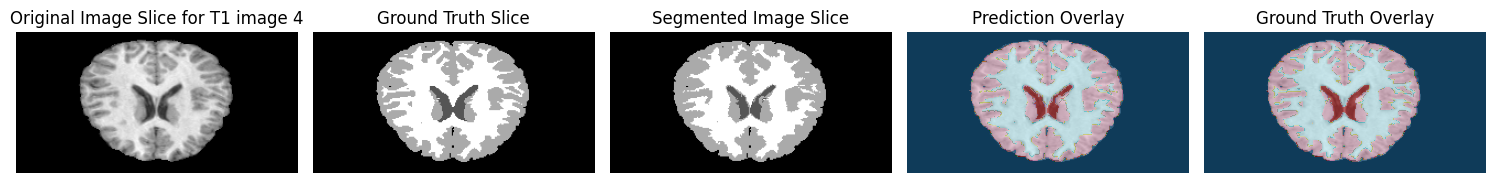

Processing image name: Validation_Set\IBSR_17\IBSR_17_normalized.nii.gz with ground truth: Validation_Set\IBSR_17\IBSR_17_seg.nii.gz
Converged at iteration 3 with log-likelihood -0.0000
Best combination has average dice score of: 0.8730721893883038
Dice Score: CSF: 0.8328987811340752, GM: 0.9302811396000119, WM: 0.8560366474308241, Avg: 0.8730721893883038


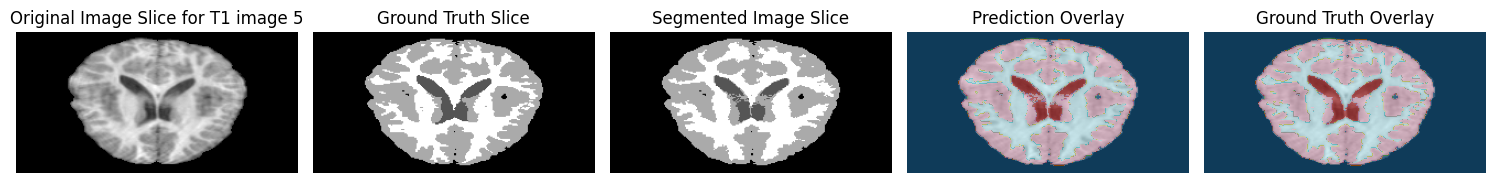

In [10]:
for i, (image_path, gt_path) in enumerate(zip(val_images, val_labels)):
    print(f"Processing image name: {image_path} with ground truth: {gt_path}")
    image = sitk.GetArrayFromImage(sitk.ReadImage(image_path))
    gt = sitk.GetArrayFromImage(sitk.ReadImage(gt_path))
    gt_label = gt.astype(bool)
    
    tissue_probs = tissue_prob(image, gt, probabilities, all_values)
    prob_atlases = [itk.imread(f'./val_probability_atlases/{os.path.splitext(image_path)[0]}/probability_atlas_{class_labels[c]}.nii.gz', itk.F) for c in range(num_classes)]
    prob_atlas = {}
    probabilitic_atlas = [itk.GetArrayFromImage(prob_atlases[i]) for i in range(1, num_classes)]
    probabilitic_atlas = [atlas[gt_label] for atlas in probabilitic_atlas]
    seg = np.stack(probabilitic_atlas, axis=0)
    
    response = EM(data=image, data_label=None, init='other', mask=gt_label, init_weights=tissue_probs, comb_mode='into', atlas_weights=seg, freq=1, max_iter=200)
    label_em = np.zeros_like(image)
    label_em[gt_label] = response + 1
    relabeled_image, segmentation, best_score = relabel(gt, label_em, image)
    show_results(image, gt, segmentation, modality='T1', i=i, slice_idx=150, plot=True, show_hist=False, cmap='tab20')

### Into EM with freq=3

Processing image name: Validation_Set\IBSR_11\IBSR_11_normalized.nii.gz with ground truth: Validation_Set\IBSR_11\IBSR_11_seg.nii.gz
Best combination has average dice score of: 0.9042798288015039
Dice Score: CSF: 0.0, GM: 0.9121341802835362, WM: 0.8964254773194718, Avg: 0.6028532192010027


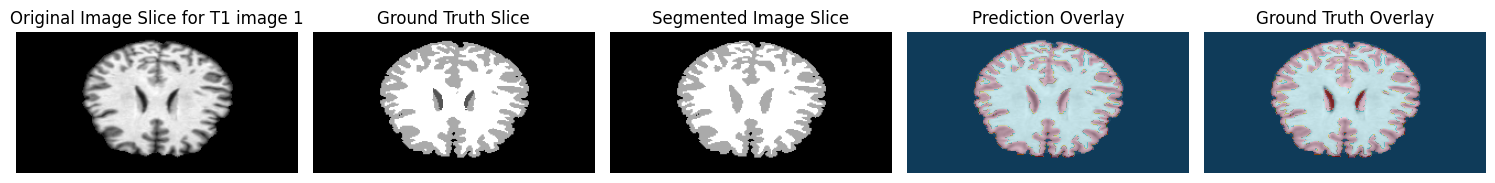

Processing image name: Validation_Set\IBSR_12\IBSR_12_normalized.nii.gz with ground truth: Validation_Set\IBSR_12\IBSR_12_seg.nii.gz
Best combination has average dice score of: 0.9120596119158748
Dice Score: CSF: 0.0, GM: 0.9297585935166761, WM: 0.8943606303150736, Avg: 0.6080397412772499


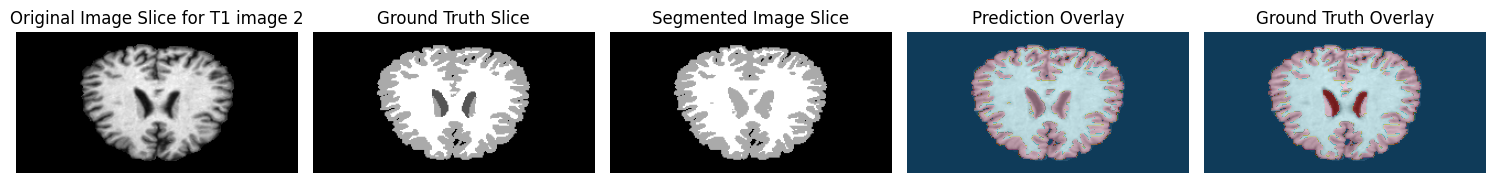

Processing image name: Validation_Set\IBSR_13\IBSR_13_normalized.nii.gz with ground truth: Validation_Set\IBSR_13\IBSR_13_seg.nii.gz
Best combination has average dice score of: 0.6141485167716375
Dice Score: CSF: 0.0714120771273525, GM: 0.9164585569806204, WM: 0.8545749162069395, Avg: 0.6141485167716375


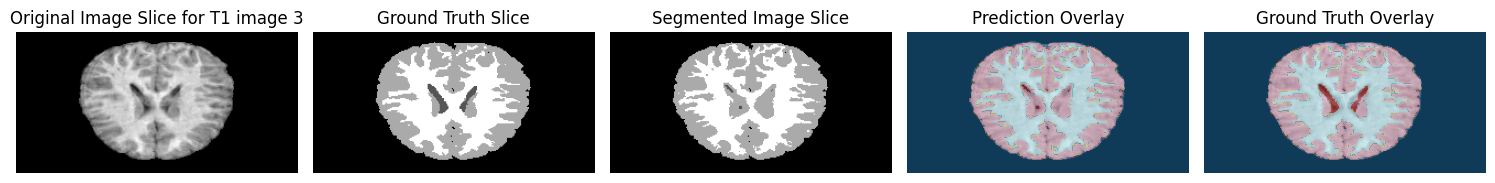

Processing image name: Validation_Set\IBSR_14\IBSR_14_normalized.nii.gz with ground truth: Validation_Set\IBSR_14\IBSR_14_seg.nii.gz
Best combination has average dice score of: 0.7187781781405324
Dice Score: CSF: 0.322515377144707, GM: 0.9338118212536817, WM: 0.9000073360232085, Avg: 0.7187781781405324


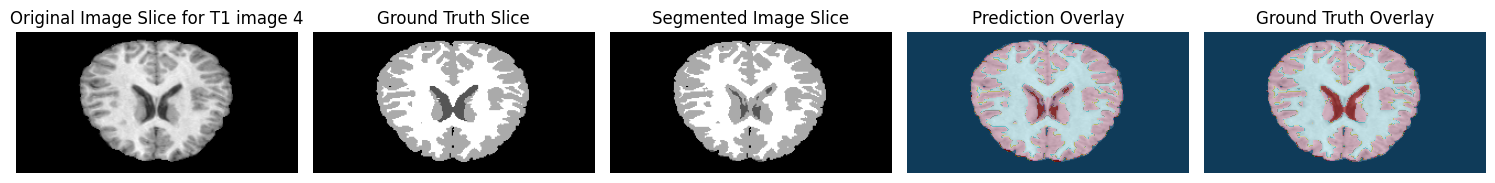

Processing image name: Validation_Set\IBSR_17\IBSR_17_normalized.nii.gz with ground truth: Validation_Set\IBSR_17\IBSR_17_seg.nii.gz
Best combination has average dice score of: 0.7490915339397727
Dice Score: CSF: 0.4258662546899139, GM: 0.9342466147840992, WM: 0.8871617323453047, Avg: 0.7490915339397727


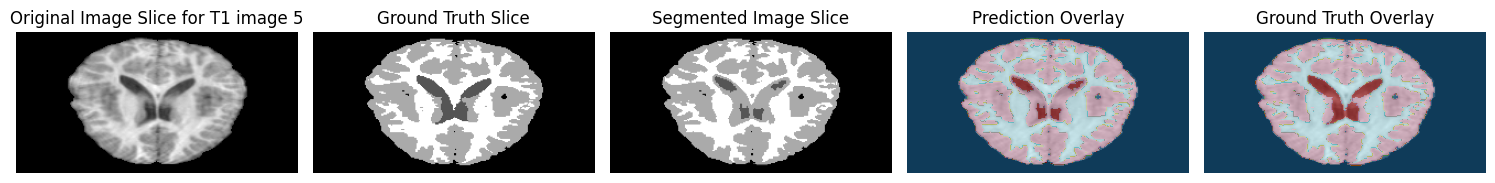

In [11]:
for i, (image_path, gt_path) in enumerate(zip(val_images, val_labels)):
    print(f"Processing image name: {image_path} with ground truth: {gt_path}")
    image = sitk.GetArrayFromImage(sitk.ReadImage(image_path))
    gt = sitk.GetArrayFromImage(sitk.ReadImage(gt_path))
    gt_label = gt.astype(bool)
    
    tissue_probs = tissue_prob(image, gt, probabilities, all_values)
    prob_atlases = [itk.imread(f'./val_probability_atlases/{os.path.splitext(image_path)[0]}/probability_atlas_{class_labels[c]}.nii.gz', itk.F) for c in range(num_classes)]
    prob_atlas = {}
    probabilitic_atlas = [itk.GetArrayFromImage(prob_atlases[i]) for i in range(1, num_classes)]
    probabilitic_atlas = [atlas[gt_label] for atlas in probabilitic_atlas]
    seg = np.stack(probabilitic_atlas, axis=0)
    
    response = EM(data=image, data_label=None, init='other', mask=gt_label, init_weights=tissue_probs, comb_mode='into', atlas_weights=seg, freq=3, max_iter=200)
    label_em = np.zeros_like(image)
    label_em[gt_label] = response + 1
    relabeled_image, segmentation, best_score = relabel(gt, label_em, image)
    show_results(image, gt, segmentation, modality='T1', i=i, slice_idx=150, plot=True, show_hist=False, cmap='tab20')

### Into EM with freq=10

Processing image name: Validation_Set\IBSR_11\IBSR_11_normalized.nii.gz with ground truth: Validation_Set\IBSR_11\IBSR_11_seg.nii.gz
Best combination has average dice score of: 0.6293359171920079
Dice Score: CSF: 0.05097312326227989, GM: 0.92677850787158, WM: 0.9102561204421638, Avg: 0.6293359171920079


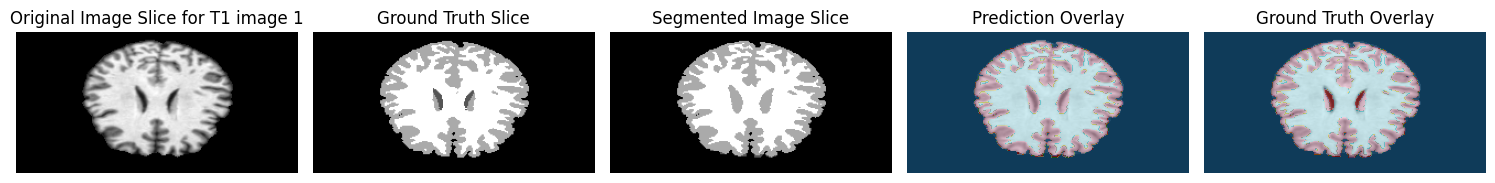

Processing image name: Validation_Set\IBSR_12\IBSR_12_normalized.nii.gz with ground truth: Validation_Set\IBSR_12\IBSR_12_seg.nii.gz
Best combination has average dice score of: 0.7230551949855203
Dice Score: CSF: 0.35895119942618814, GM: 0.9237594140101104, WM: 0.8864549715202625, Avg: 0.7230551949855203


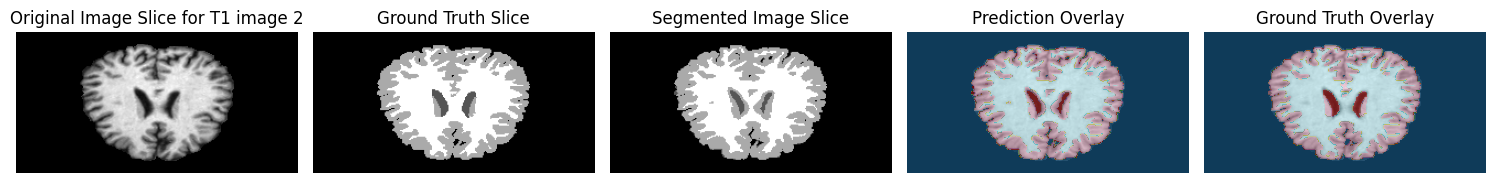

Processing image name: Validation_Set\IBSR_13\IBSR_13_normalized.nii.gz with ground truth: Validation_Set\IBSR_13\IBSR_13_seg.nii.gz
Best combination has average dice score of: 0.4505104054679559
Dice Score: CSF: 0.1219513858112024, GM: 0.5869365225390984, WM: 0.6426433080535668, Avg: 0.4505104054679559


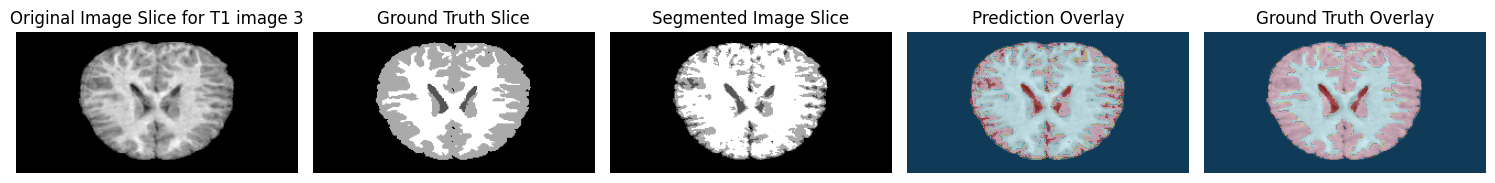

Processing image name: Validation_Set\IBSR_14\IBSR_14_normalized.nii.gz with ground truth: Validation_Set\IBSR_14\IBSR_14_seg.nii.gz
Best combination has average dice score of: 0.7583319173747466
Dice Score: CSF: 0.4519796817707808, GM: 0.933339167155955, WM: 0.8896769031975039, Avg: 0.7583319173747466


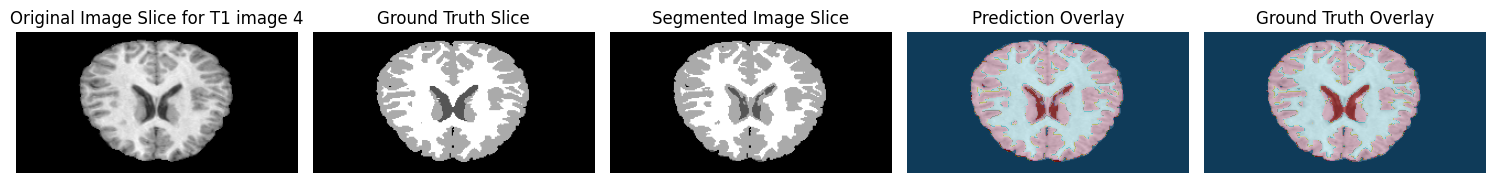

Processing image name: Validation_Set\IBSR_17\IBSR_17_normalized.nii.gz with ground truth: Validation_Set\IBSR_17\IBSR_17_seg.nii.gz
Best combination has average dice score of: 0.7754451096522444
Dice Score: CSF: 0.5013468076015679, GM: 0.9368224871559394, WM: 0.8881660341992261, Avg: 0.7754451096522444


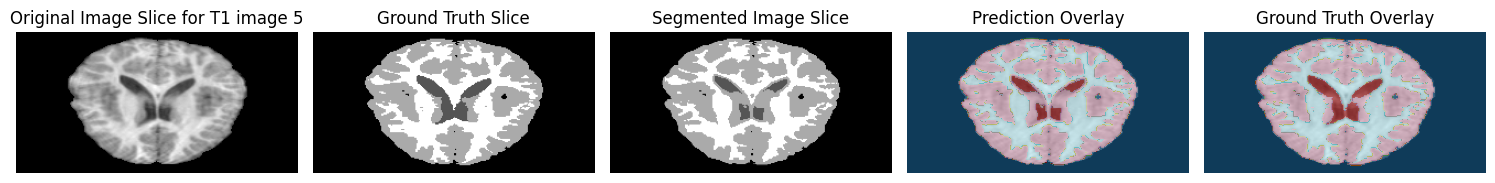

In [12]:
for i, (image_path, gt_path) in enumerate(zip(val_images, val_labels)):
    print(f"Processing image name: {image_path} with ground truth: {gt_path}")
    image = sitk.GetArrayFromImage(sitk.ReadImage(image_path))
    gt = sitk.GetArrayFromImage(sitk.ReadImage(gt_path))
    gt_label = gt.astype(bool)
    
    tissue_probs = tissue_prob(image, gt, probabilities, all_values)
    prob_atlases = [itk.imread(f'./val_probability_atlases/{os.path.splitext(image_path)[0]}/probability_atlas_{class_labels[c]}.nii.gz', itk.F) for c in range(num_classes)]
    prob_atlas = {}
    probabilitic_atlas = [itk.GetArrayFromImage(prob_atlases[i]) for i in range(1, num_classes)]
    probabilitic_atlas = [atlas[gt_label] for atlas in probabilitic_atlas]
    seg = np.stack(probabilitic_atlas, axis=0)
    
    response = EM(data=image, data_label=None, init='other', mask=gt_label, init_weights=tissue_probs, comb_mode='into', atlas_weights=seg, freq=10, max_iter=200)
    label_em = np.zeros_like(image)
    label_em[gt_label] = response + 1
    relabeled_image, segmentation, best_score = relabel(gt, label_em, image)
    show_results(image, gt, segmentation, modality='T1', i=i, slice_idx=150, plot=True, show_hist=False, cmap='tab20')

In [ ]:
# voxel wsie comparison

## Result Analysis

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

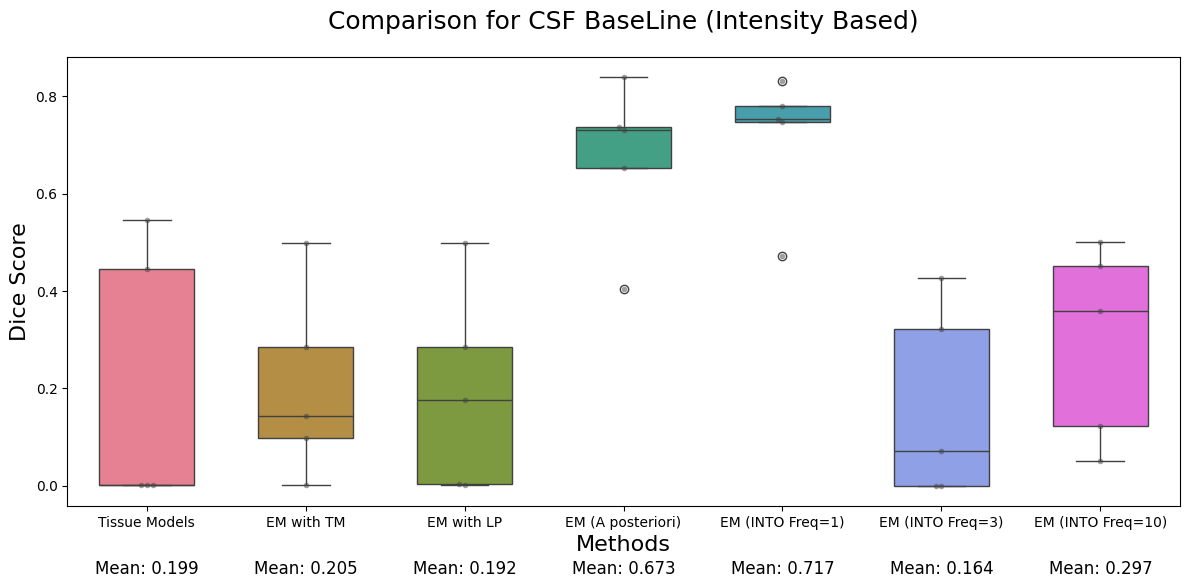

In [6]:
csf_values_tissue_models = [0.5460, 0.4454, 0.0019, 0.00014, 0.0016]
csf_values_EM_tissue_models = [0.0986, 0.1429, 0.0005, 0.2850, 0.4980]
csf_values_EM_label_propagation = [0.0025, 0.1752, 0.0005, 0.2850, 0.4980]
csf_values_EM_tissue_models_and_label_propagation_aposteriori = [0.7378,0.6532,0.4044,0.7310,0.8398,]
csf_values_EM_tissue_models_and_label_propagation_freq_1 = [0.7466,0.7809,0.4725,0.7543,0.8328,]
csf_values_EM_tissue_models_and_label_propagation_freq_3 = [0.0,0.0,0.0714,0.3225,0.4258,]
csf_values_EM_tissue_models_and_label_propagation_freq_10 = [0.0509,0.3589,0.1219,0.4519,0.5013,]
data = {
    'Tissue Models': csf_values_tissue_models,
    'EM with TM': csf_values_EM_tissue_models,
    'EM with LP': csf_values_EM_label_propagation,
    'EM (A posteriori)': csf_values_EM_tissue_models_and_label_propagation_aposteriori,
    'EM (INTO Freq=1)': csf_values_EM_tissue_models_and_label_propagation_freq_1,
    'EM (INTO Freq=3)': csf_values_EM_tissue_models_and_label_propagation_freq_3,
    'EM (INTO Freq=10)': csf_values_EM_tissue_models_and_label_propagation_freq_10
}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for CSF BaseLine (Intensity Based)', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Methods', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.14, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

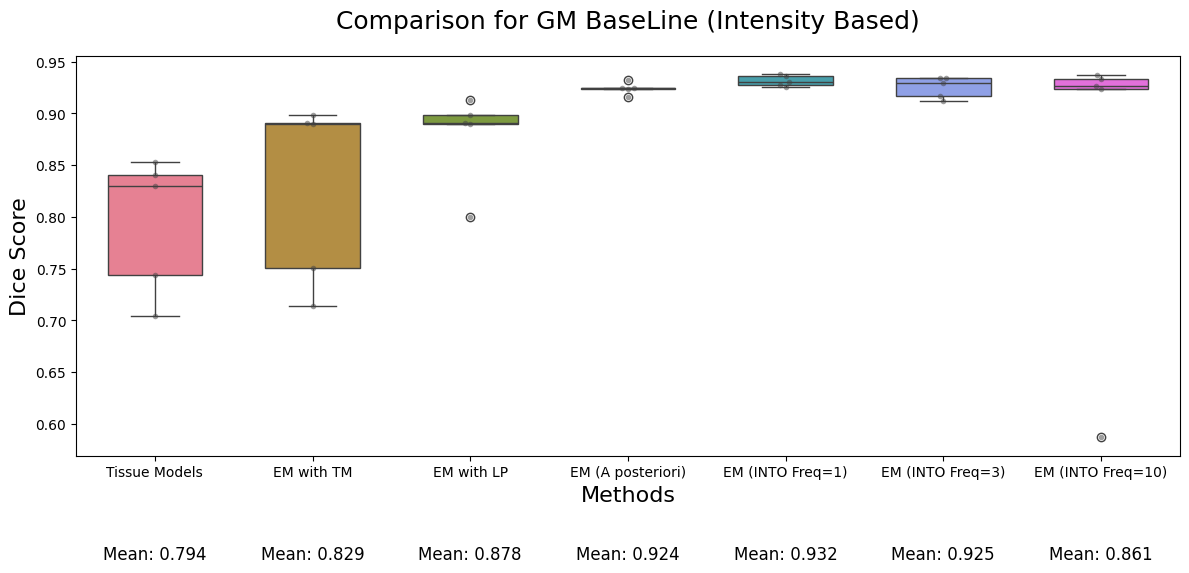

In [7]:
gm_values_EM_tissue_models = [0.7134, 0.7505,0.8909,0.8986, 0.8897]
gm_values_tissue_models = [0.7434, 0.8400, 0.7043, 0.8294,0.8533]
gm_values_EM_label_propagation = [0.9125, 0.7995, 0.8908, 0.8983, 0.8897]
gm_values_EM_tissue_models_and_label_propagation_aposteriori = [0.9246,0.9161,0.9321,0.9239,0.92421,]
gm_values_EM_tissue_models_and_label_propagation_freq_1=[0.9275,0.9364,0.9256,0.9380,0.9302,]
gm_values_EM_tissue_models_and_label_propagation_freq_3 = [0.9121,0.9297,0.9164,0.9338,0.9342,]
gm_values_EM_tissue_models_and_label_propagation_freq_10 =[0.9267,0.9237,0.5869,0.9333,0.9368,]

data = {
    'Tissue Models': gm_values_tissue_models,
    'EM with TM': gm_values_EM_tissue_models,
    'EM with LP': gm_values_EM_label_propagation,
    'EM (A posteriori)': gm_values_EM_tissue_models_and_label_propagation_aposteriori,
    'EM (INTO Freq=1)': gm_values_EM_tissue_models_and_label_propagation_freq_1,
    'EM (INTO Freq=3)': gm_values_EM_tissue_models_and_label_propagation_freq_3,
    'EM (INTO Freq=10)': gm_values_EM_tissue_models_and_label_propagation_freq_10
}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for GM BaseLine (Intensity Based)', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Methods', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.10, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

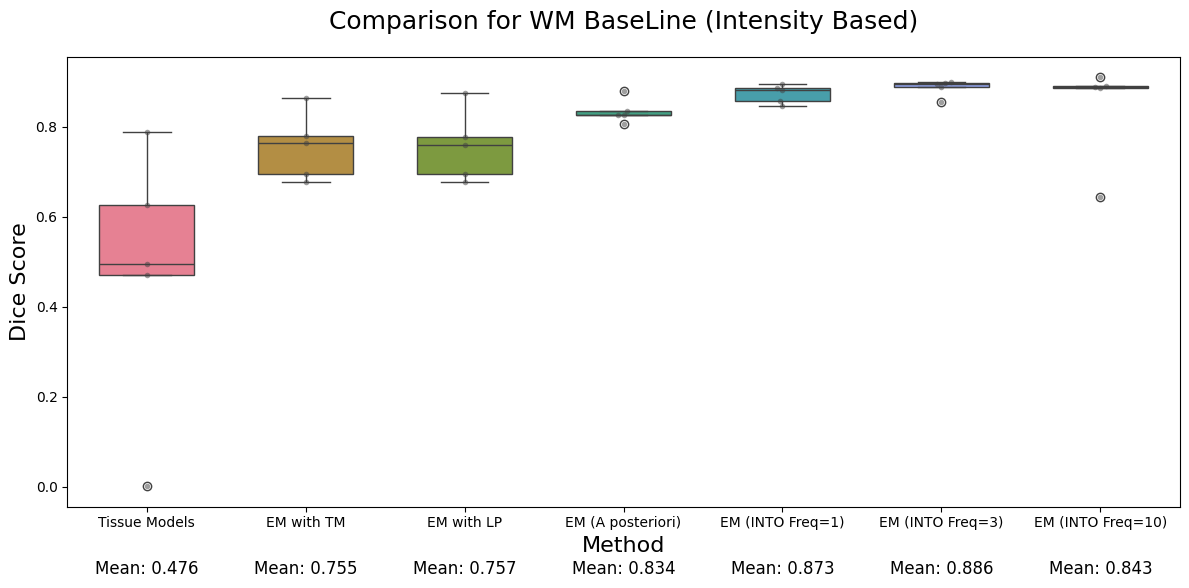

In [8]:
wm_values_tissue_models = [ 0.0013, 0.4954, 0.6252, 0.788, 0.4695   ]
wm_values_EM_tissue_models= [0.8637, 0.7641, 0.6763, 0.7786, 0.69471]
wm_values_EM_label_propagation = [0.8748, 0.7602, 0.6759, 0.7775, 0.6947]
wm_values_EM_tissue_models_and_label_propagation_aposteriori = [0.8782,0.8265,0.8250,0.8351,0.8067,    ]
wm_values_EM_tissue_models_and_label_propagation_freq_1 =[ 0.8952,0.8814,0.8449,0.8860,0.8560,]
wm_values_EM_tissue_models_and_label_propagation_freq_3=[0.8964,0.8943,0.8545,0.9000,0.8871,]
wm_values_EM_tissue_models_and_label_propagation_freq_10= [0.91025,0.8864,0.6426,0.8896,0.8881,]
data = {
    'Tissue Models': wm_values_tissue_models,
    'EM with TM': wm_values_EM_tissue_models,
    'EM with LP': wm_values_EM_label_propagation,
    'EM (A posteriori)': wm_values_EM_tissue_models_and_label_propagation_aposteriori,
    'EM (INTO Freq=1)': wm_values_EM_tissue_models_and_label_propagation_freq_1,
    'EM (INTO Freq=3)': wm_values_EM_tissue_models_and_label_propagation_freq_3,
    'EM (INTO Freq=10)': wm_values_EM_tissue_models_and_label_propagation_freq_10
}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for WM BaseLine (Intensity Based)', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Method', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.15, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()